## Check for Spatial Autocorrelation and Data Leakage


The deprivation data will definitely be spatially autocorrelated, and the CLIP embeddings probably are too.
This leads to data leakage in the models as an LSOA in the test set will be similar to its neighbours in the training set.
This script quantifies how much difference that makes to the base model of script 4 and for the Alpha Earth models.

It does four things:

1. Tests the **target** (`imd_rank`) for spatial autocorrelation — Moran's I.
2. Tests the **predictors** (the 512 CLIP embedding dimensions) for spatial autocorrelation.
3. Tests the **out-of-fold residuals** of the script 4 model for spatial autocorrelation.
4. Re-runs the script 4 model under a **spatial cross-validation** using the Local Authority Districts that all LSOAs
    are nested within ('leave-one-LAD-out') and compares the R² to the random-CV figure.

### Dependencies
**Prerequisites:** Script 3 (per-LSOA embedding summaries), script 4 (saved base model),
scripts 9a/9b (AlphaEarth embeddings and model) for the final comparison.

**Inputs:**
- `data/processed/per_lsoa_embedding_summaries/median_embedding.pkl` — per-LSOA CLIP embeddings (script 3)
- `data/processed/per_lsoa_embedding_summaries/alphaearth_embeddings.pkl` — per-LSOA satellite embeddings (script 9a)
- `data/models/best_model.joblib` — street-view model (script 4)
- `data/models/best_model_alphaearth.joblib` — satellite model (script 9b)
- IMD Excel file (via `imd_file`), LSOA shapefile (via `lsoas_file`)
- `spatial_diagnostics.py` — weights, Moran's I, out-of-fold prediction, pooled scoring
- `clustering_functions.py` — `RANDOM_STATE`, `embedding_statistic`

**Outputs:**
- `outputs/11-embedding_morans_i.pdf` — distribution of Moran's I across embedding dimensions
- `outputs/11-residuals_random_cv.pdf` — map of out-of-fold residuals, random CV
- `outputs/11-residuals_spatial_cv.pdf` — map of out-of-fold residuals, leave-one-LAD-out CV
- `outputs/11-spatial_diagnostics.tex` — summary tables for the paper

**Requires** `esda` and `libpysal` (added to `environment.yml`).

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*glibc.*")

import os

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import KFold, GroupKFold

In [2]:
from directory_filepaths import *
from clustering_functions import RANDOM_STATE, embedding_statistic
import spatial_diagnostics as sd

## A. Load the same data as script 4

The data are assembled exactly as in script 4 (same files, same merge, same row order), so
that the diagnostics below apply to precisely the dataset the base model was trained on.

In [3]:
var_to_predict = 'imd_rank'

# Aggregation statistic is defined centrally in clustering_functions.py
statistic = embedding_statistic
print(f"Using '{statistic}' embedding aggregation (from clustering_functions.py)")

Using 'median' embedding aggregation (from clustering_functions.py)


In [4]:
# --- IMD (as script 4) ---
imd = pd.read_excel(imd_file, sheet_name="IoD2025 Domains", header=0)

imd_col_map = {"LSOA code (2021)": "LSOA21CD",
    "Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)": "imd_rank",
    "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)": "imd_decile"}
imd = imd.rename(columns=imd_col_map)

# --- Embeddings (as script 4) ---
embedding_pkl = os.path.join(data_dir, "per_lsoa_embedding_summaries", f"{statistic}_embedding.pkl")
big_summary_df = pd.read_pickle(embedding_pkl)

df = pd.merge(left=big_summary_df, right=imd[['LSOA21CD', 'imd_rank']], on="LSOA21CD")
print(f"LSOAs with both embeddings and IMD data: {len(df)}")

LSOAs with both embeddings and IMD data: 1695


### Attach geometry and local authority districts

We need LSOA polygons and local authority district (LAD) codes.

The polygons are kept in **EPSG:27700** (British National Grid) rather than the EPSG:4326 used
elsewhere in the project, so that any distance calculation is in metres rather than degrees.

Note the row order: `gm` is built to match `df` row-for-row, and neither is reordered afterwards.
The spatial weights are positional, so this alignment must remain for the rest of the script.

In [5]:
lsoas = gpd.read_file(lsoas_file)
manc_lads = ['Manchester', 'Rochdale', 'Bolton', 'Bury', 'Wigan', 'Oldham', 'Trafford', 'Salford', 'Tameside', 'Stockport']
gm_lsoa = lsoas[lsoas['LSOA21NM'].str.contains('|'.join(manc_lads))].to_crs(epsg=27700)

# Left-merge onto df so the geometry rows line up with the model rows exactly.
gm = df[['LSOA21CD']].merge(
    gm_lsoa[['LSOA21CD', 'LSOA21NM', 'geometry']], on='LSOA21CD', how='left')
gm = gpd.GeoDataFrame(gm, geometry='geometry', crs=gm_lsoa.crs)

# The LAD is the LSOA name minus its trailing number+letter ("Manchester 001A" -> "Manchester")
gm['LAD'] = sd.lad_groups(gm)

# --- Sanity checks ---
assert (gm['LSOA21CD'] == df['LSOA21CD']).all(), "Geometry rows are not aligned with model rows"
assert gm['geometry'].notna().all(), "Some LSOAs have no geometry"
assert gm['LAD'].nunique() == 10, f"Expected 10 GM local authorities, got {gm['LAD'].nunique()}"

print(f"{len(gm)} LSOAs across {gm['LAD'].nunique()} local authorities:")
print(gm['LAD'].value_counts().to_string())

1695 LSOAs across 10 local authorities:
LAD
Manchester    292
Wigan         200
Stockport     190
Bolton        177
Salford       158
Oldham        142
Tameside      142
Trafford      139
Rochdale      135
Bury          120


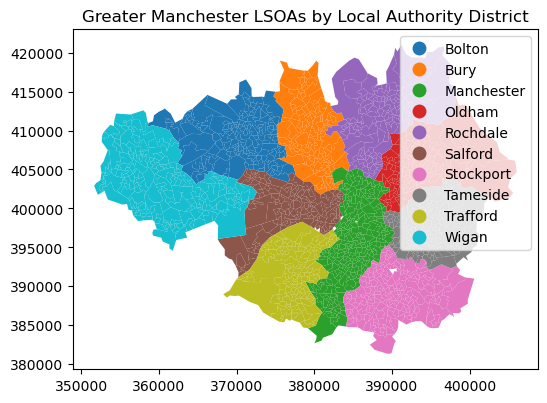

In [6]:
# Sanity check: map the LSOAs and LADS, colouring by LAD
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
gm.plot(column='LAD', cmap='tab10', legend=True, ax=ax)
ax.set_title("Greater Manchester LSOAs by Local Authority District")
#os.makedirs(outputs_dir, exist_ok=True)
#fig.savefig(os.path.join(outputs_dir, "11-gm_lsoas_by_lad.pdf"), bbox_inches="tight")
plt.show()

In [7]:
# Feature matrix and target, as script 4 builds them
X = np.stack(df[f"{statistic}_embedding"].values)
y = df[var_to_predict].values.astype(float)
groups = gm['LAD'].values

print(f"X: {X.shape}, y: {y.shape}")

X: (1695, 512), y: (1695,)


## B. Is the target (LSOA deprivation) spatially autocorrelated?

Global Moran's I on `imd_rank`, using a row-standardised **queen contiguity** weights matrix
(LSOAs are neighbours if their polygons share an edge or a corner).

Moran's I behaves like a correlation between each LSOA's value and the average of its
neighbours' values: near +1 means strong clustering, 0 means no spatial pattern. Significance
is assessed by reshuffling the values across space 999 times, so no distributional
assumptions are needed.

In [8]:
print("Building spatial weights matrix...")
w = sd.build_weights(gm, verbose=True)

Building spatial weights matrix...
  Queen contiguity: 1695 LSOAs, mean 5.9 neighbours each


 LSOA21CD        LSOA21NM        LAD  n_neighbours
E01004785     Bolton 006B     Bolton             8
E01004950       Bury 010B       Bury             8
E01005149 Manchester 008C Manchester             6
E01005438     Oldham 029E     Oldham             9
E01005509   Rochdale 018F   Rochdale             4
E01005662    Salford 004B    Salford             6
E01005887  Stockport 002A  Stockport             6
E01006008   Tameside 017A   Tameside            10
E01006157   Trafford 006B   Trafford            14
E01006322      Wigan 026D      Wigan            11


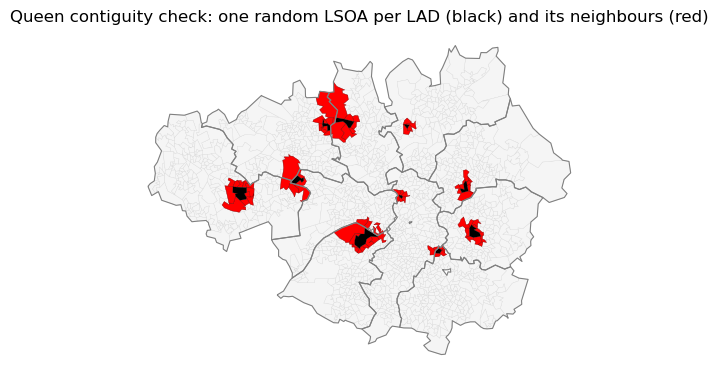

In [9]:
# Sanity check: chose one LSOA from each LAD, map it in black, and map its neighbours in red.
picks = gm.groupby('LAD').sample(1, random_state=RANDOM_STATE).index
neighbours = sorted({n for i in picks for n in w.neighbors[i]} - set(picks))

ax = gm.plot(figsize=(6, 6), color='whitesmoke', edgecolor='lightgrey', linewidth=0.2)
gm.dissolve(by='LAD').boundary.plot(ax=ax, color='grey', linewidth=0.8)
gm.loc[neighbours].plot(ax=ax, color='red', edgecolor='darkred', linewidth=0.3)
gm.loc[picks].plot(ax=ax, color='black')   # drawn last so a pick is never hidden by a neighbour
ax.set_title("Queen contiguity check: one random LSOA per LAD (black) and its neighbours (red)")
ax.set_axis_off()

print(gm.loc[picks, ['LSOA21CD', 'LSOA21NM', 'LAD']].assign(
    n_neighbours=[len(w.neighbors[i]) for i in picks]).to_string(index=False))

In [10]:
imd_moran = sd.morans(y, w, permutations=999, label="imd_rank")

print(f"Moran's I for {var_to_predict}: {imd_moran['I']:.3f} "
      f"(expected under no spatial pattern: {imd_moran['E[I]']:.4f})")
print(f"  z = {imd_moran['z']:.1f}, pseudo p = {imd_moran['p']:.4f}")

Moran's I for imd_rank: 0.551 (expected under no spatial pattern: -0.0006)
  z = 37.9, pseudo p = 0.0010


## C. Are the *predictors* (embeddings) spatially autocorrelated?

Leakage through a random fold requires spatial autocorrelation on **both** sides of the model.
Moran's I is run on each of the 512 CLIP dimensions separately and the *distribution* of I is
summarised. Fewer permutations (99) are used here because only the _shape_ of the distribution
is needed.

In [11]:
print(f"Running Moran's I on {X.shape[1]} embedding dimensions (99 permutations each)...")
emb_moran = sd.morans_many(X, w, permutations=99)

sig = (emb_moran['p'] < 0.05).mean()  # (proportion of dimensions with True for x<0.05)
print(f"\nMoran's I across {len(emb_moran)} embedding dimensions:")
print(f"  median      = {emb_moran['I'].median():.3f}")
print(f"  IQR         = {emb_moran['I'].quantile(0.25):.3f} to {emb_moran['I'].quantile(0.75):.3f}")
print(f"  min / max   = {emb_moran['I'].min():.3f} / {emb_moran['I'].max():.3f}")
print(f"  significant at p<0.05: {sig:.1%} of dimensions")

Running Moran's I on 512 embedding dimensions (99 permutations each)...

Moran's I across 512 embedding dimensions:
  median      = 0.358
  IQR         = 0.299 to 0.439
  min / max   = 0.113 / 0.681
  significant at p<0.05: 100.0% of dimensions


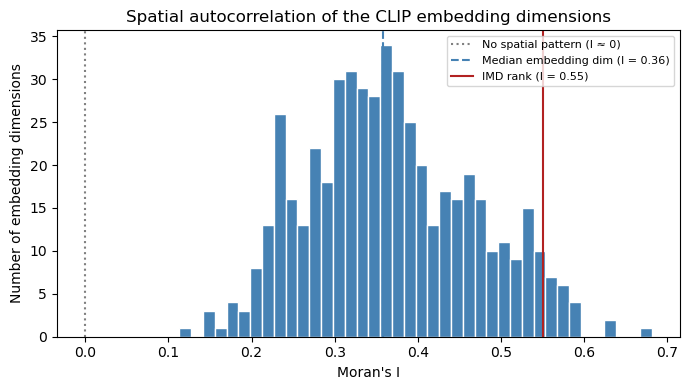

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(emb_moran['I'], bins=40, color='steelblue', edgecolor='white')
ax.axvline(0, color='grey', linestyle=':', label="No spatial pattern (I \u2248 0)")
ax.axvline(emb_moran['I'].median(), color='steelblue', linestyle='--',
           label=f"Median embedding dim (I = {emb_moran['I'].median():.2f})")
ax.axvline(imd_moran['I'], color='firebrick', linestyle='-',
           label=f"IMD rank (I = {imd_moran['I']:.2f})")
ax.set_xlabel("Moran's I")
ax.set_ylabel("Number of embedding dimensions")
ax.set_title("Spatial autocorrelation of the CLIP embedding dimensions")
ax.legend(fontsize=8)
fig.tight_layout()

os.makedirs(outputs_dir, exist_ok=True)
fig.savefig(os.path.join(outputs_dir, "11-embedding_morans_i.pdf"), bbox_inches="tight")
plt.show()

## D. Out-of-fold residuals under the current (random) cross-validation

To test residuals for spatial autocorrelation, every residual must come from a model that had
**not** seen that LSOA. LSOA residuals were calculated in script 4, but these were from a model
that had already been trained on 80% of the LSOAs, so was useful as a visualisation but cannot
be used for Moran's I.

Theferofe here the script 4 model is refitted across the same
`KFold(n_splits=5, shuffle=True)` folds, and each LSOA's prediction is taken from the fold in
which it was held out.

Note: this means that R² here differs slightly from script 4's.
The cross-validator is identical to script 4's (KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)),
but here it is applied to all 1,695 LSOAs rather than to script 4's 80% training split. This is because
Moran's I needs a residual for every LSOA, not just 80% of them.


In [13]:
# The saved pipeline (StandardScaler -> XGBRegressor) with the hyperparameters script 4 chose
sv_bundle = joblib.load(os.path.join("../data/models/best_model.joblib"))
best_model = sv_bundle['model']

print(f"Loaded script 4 model: {sv_bundle['name']}")
print(f"  reported random-CV R\u00b2   = {sv_bundle['cv_score_r2']:.3f}")
print(f"  reported random-CV NRMSE = {sv_bundle['cv_nrmse']:.3f}")
print(f"  hyperparameters: {sv_bundle['best_params']}")

Loaded script 4 model: XGBoost
  reported random-CV R²   = 0.660
  reported random-CV NRMSE = 0.582
  hyperparameters: {'reg__learning_rate': 0.1, 'reg__max_depth': 3, 'reg__n_estimators': 300, 'reg__subsample': 1.0}


In [14]:
random_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

y_pred_random = sd.out_of_fold_predictions(best_model, X, y, random_cv)
resid_random = y - y_pred_random

random_scores = sd.pooled_scores(y, y_pred_random)
print("Street-view model, random 5-fold CV (pooled out-of-fold):")
for k, v in random_scores.items():
    print(f"  {k}: {v:.3f}")

Street-view model, random 5-fold CV (pooled out-of-fold):
  R2: 0.658
  RMSE: 6108.313
  NRMSE: 0.585
  Spearman: 0.801


## E. Moran's I on the random-CV residuals

This tests whether there is some spatial structure left in the residuals.
A **high** value would mean the model leaves spatial structure unexplained — evidence of a
spatially varying influence on deprivation that the imagery does not capture.

In [15]:
resid_random_moran = sd.morans(resid_random, w, permutations=999, label="residuals (random CV)")

print(f"Moran's I of out-of-fold residuals (random CV): {resid_random_moran['I']:.3f}")
print(f"  z = {resid_random_moran['z']:.1f}, pseudo p = {resid_random_moran['p']:.4f}")
print(f"  (for comparison, IMD rank itself: I = {imd_moran['I']:.3f})")

Moran's I of out-of-fold residuals (random CV): 0.196
  z = 13.9, pseudo p = 0.0010
  (for comparison, IMD rank itself: I = 0.551)


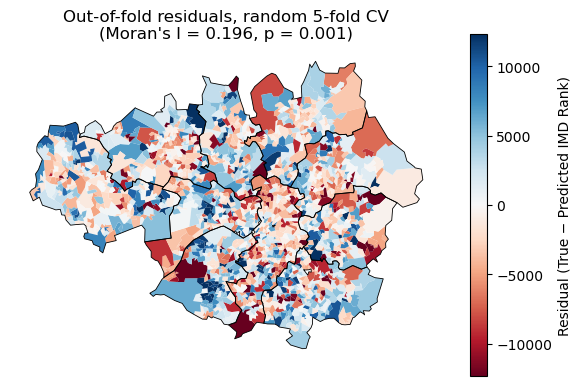

In [16]:
def plot_residual_map(residuals, title, filename):
    """Choropleth of out-of-fold residuals, on a symmetric colour scale."""
    gm_plot = gm.copy()
    gm_plot['residual'] = residuals

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    vmax = np.percentile(np.abs(residuals), 95)  # clip at the 95th percentile so outliers don't dominate
    gm_plot.plot(
        column='residual',
        cmap='RdBu',      # red = over-predicted rank (model thinks less deprived than it is)
        vmin=-vmax,       # blue = under-predicted rank (model thinks more deprived than it is)
        vmax=vmax,
        legend=True,
        legend_kwds={'label': 'Residual (True \u2212 Predicted IMD Rank)', 'shrink': 0.6},
        ax=ax)
    gm.dissolve(by='LAD').boundary.plot(ax=ax, linewidth=0.6, color='black')  # LAD outlines
    ax.set_title(title)
    ax.set_axis_off()
    fig.tight_layout()
    fig.savefig(os.path.join(outputs_dir, filename), bbox_inches="tight")
    plt.show()


plot_residual_map(
    resid_random,
    f"Out-of-fold residuals, random 5-fold CV\n(Moran's I = {resid_random_moran['I']:.3f}, p = {resid_random_moran['p']:.3f})",
    "11-residuals_random_cv.pdf")

The results suggest that although the model remains significantly spatially autocorrelated (I=0.196) there is much less autocorrelation than in the IMD ranks (I=0.551). This suggests that the embeddings capture much, but not all, of the spatial structure.

## F. Spatial cross-validation: leave-one-LAD-out

Greater Manchester is made up of exactly 10 local authority districts, which gives a natural
spatial blocking scheme (train on the LSOAs in 9 LADs, test on the remainder). Each fold
holds out one entire district, so no held-out LSOA has *any* neighbour in the training set
(except across the district boundary itself).

The model keeps the hyperparameters script 4 selected, so the splitter is the only thing
that changes and any difference from the random-CV result is attributable to it.

**A note on pooled scoring:**

Per-fold R² is unreliable here. The districts differ sharply in their deprivation
distributions (Manchester vs Trafford), and R² is measured against the variance of whatever is
in the fold — so a district with a narrow spread of IMD ranks scores badly even under a good
model. **Pooled** out-of-fold R² (all held-out predictions scored together, against the global
mean) is therefore the headline; the mean-of-folds figure is reported alongside it because that
is the form script 4's own number takes.

In [17]:
spatial_cv = GroupKFold(n_splits=10)

# Script 4's hyperparameters, evaluated under spatial folds (groups are LADs)
y_pred_spatial = sd.out_of_fold_predictions(best_model, X, y, spatial_cv, groups=groups)
resid_spatial = y - y_pred_spatial

spatial_scores = sd.pooled_scores(y, y_pred_spatial)
print("Street-view model, leave-one-LAD-out CV (pooled out-of-fold):")
for k, v in spatial_scores.items():
    print(f"  {k}: {v:.3f}")


Street-view model, leave-one-LAD-out CV (pooled out-of-fold):
  R2: 0.623
  RMSE: 6408.302
  NRMSE: 0.614
  Spearman: 0.778


In [18]:
# Per-fold breakdown: which districts are hard to predict when held out entirely?
fold_table = sd.per_fold_scores(y, X, spatial_cv, best_model, groups=groups)
fold_table = fold_table.sort_values('R2', ascending=False)
print(f"\nMean of per-fold R\u00b2: {fold_table['R2'].mean():.3f} "
      f"(vs pooled {spatial_scores['R2']:.3f})")
fold_table


Mean of per-fold R²: 0.543 (vs pooled 0.623)


,fold,held_out_group,n_test,R2,RMSE,NRMSE
8,8,Rochdale,135,0.729112,4644.769223,0.520469
3,3,Bolton,177,0.678217,5918.771577,0.567259
1,1,Wigan,200,0.674451,5976.325913,0.570569
6,6,Oldham,142,0.649390,5529.133306,0.592124
2,2,Stockport,190,0.633924,6309.351765,0.605042
9,9,Bury,120,0.605214,6080.567611,0.628320
5,5,Tameside,142,0.527751,5949.902308,0.687204
4,4,Salford,158,0.437279,6997.548185,0.750147
7,7,Trafford,139,0.344904,7973.970889,0.809380
0,0,Manchester,292,0.151405,7264.057082,0.921192


**These are the useful figures: what is the R2 with pooling under (i) random CV (like before) and spatial CV (leave-one-LAD-out):**

In [21]:
# How much does spatial blocking cost?
drop = random_scores['R2'] - spatial_scores['R2']
print(f"Pooled R\u00b2 under random CV:  {random_scores['R2']:.3f}")
print(f"Pooled R\u00b2 under spatial CV: {spatial_scores['R2']:.3f}")
print(f"Difference: {drop:+.3f} "
      f"({100 * drop / random_scores['R2']:+.1f}% of the random-CV figure)")


Pooled R² under random CV:  0.658
Pooled R² under spatial CV: 0.623
Difference: +0.034 (+5.2% of the random-CV figure)


## G. Moran's I on the spatial-CV residuals

The same residual test as section E, but on residuals from the spatially blocked model.

In [22]:
resid_spatial_moran = sd.morans(resid_spatial, w, permutations=999, label="residuals (spatial CV)")

print(f"Moran's I of out-of-fold residuals (leave-one-LAD-out CV): {resid_spatial_moran['I']:.3f}")
print(f"  z = {resid_spatial_moran['z']:.1f}, pseudo p = {resid_spatial_moran['p']:.4f}")
print(f"  (random CV residuals: I = {resid_random_moran['I']:.3f})")

Moran's I of out-of-fold residuals (leave-one-LAD-out CV): 0.253
  z = 17.7, pseudo p = 0.0010
  (random CV residuals: I = 0.196)


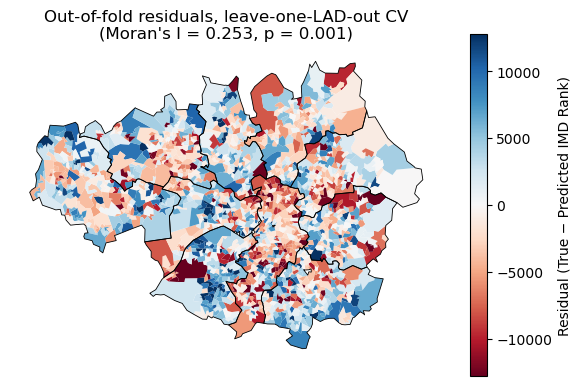

In [23]:
plot_residual_map(
    resid_spatial,
    f"Out-of-fold residuals, leave-one-LAD-out CV\n(Moran's I = {resid_spatial_moran['I']:.3f}, p = {resid_spatial_moran['p']:.3f})",
    "11-residuals_spatial_cv.pdf")

## H. AlphaEarth residuals

A residual autocorrelation test for the satellite model too, so that the diagnostic is not
applied selectively to only one of the two models being compared.


In [24]:
ae_bundle = joblib.load(os.path.join("../data/models/best_model_alphaearth.joblib"))
ae_model = ae_bundle['model']

ae_pkl = os.path.join(data_dir, "per_lsoa_embedding_summaries", "alphaearth_embeddings.pkl")
ae_df = pd.read_pickle(ae_pkl)

# Align the AlphaEarth rows to the same LSOAs, in the same order, as the street-view analysis
ae_aligned = df[['LSOA21CD', var_to_predict]].merge(
    ae_df[['LSOA21CD', f"{statistic}_embedding"]], on='LSOA21CD', how='inner')

assert (ae_aligned['LSOA21CD'] == df['LSOA21CD']).all(), \
    "AlphaEarth LSOAs differ from the street-view set - the weights matrix would not align"

X_ae = np.stack(ae_aligned[f"{statistic}_embedding"].values)
print(f"AlphaEarth X: {X_ae.shape} (reported random-CV R\u00b2 = {ae_bundle['cv_score_r2']:.3f})")

AlphaEarth X: (1695, 64) (reported random-CV R² = 0.324)


In [25]:
y_pred_ae = sd.out_of_fold_predictions(ae_model, X_ae, y, random_cv)
resid_ae = y - y_pred_ae

ae_scores = sd.pooled_scores(y, y_pred_ae)
resid_ae_moran = sd.morans(resid_ae, w, permutations=999, label="residuals (AlphaEarth, random CV)")

print("AlphaEarth model, random 5-fold CV (pooled out-of-fold):")
for k, v in ae_scores.items():
    print(f"  {k}: {v:.3f}")
print(f"\nMoran's I of AlphaEarth residuals: {resid_ae_moran['I']:.3f} "
      f"(z = {resid_ae_moran['z']:.1f}, pseudo p = {resid_ae_moran['p']:.4f})")

AlphaEarth model, random 5-fold CV (pooled out-of-fold):
  R2: 0.353
  RMSE: 8396.621
  NRMSE: 0.804
  Spearman: 0.597

Moran's I of AlphaEarth residuals: 0.260 (z = 18.2, pseudo p = 0.0010)


## I. Summary

Two tables, both exported to `outputs/11-spatial_diagnostics.tex` for the paper.

In [27]:
moran_table = pd.DataFrame([
    {"Variable": "IMD rank (target)", **{k: imd_moran[k] for k in ("I", "z", "p")}},
    {"Variable": "CLIP embedding dimensions (median of 512)",
     "I": emb_moran['I'].median(), "z": emb_moran['z'].median(), "p": emb_moran['p'].median()},
    {"Variable": "Street-view residuals, random CV", **{k: resid_random_moran[k] for k in ("I", "z", "p")}},
    {"Variable": "Street-view residuals, spatial CV", **{k: resid_spatial_moran[k] for k in ("I", "z", "p")}},
    {"Variable": "AlphaEarth residuals, random CV", **{k: resid_ae_moran[k] for k in ("I", "z", "p")}},
]).set_index("Variable")

moran_table.round(3)

,I,z,p
Variable,,,
IMD rank (target),0.551,37.929,0.001
CLIP embedding dimensions (median of 512),0.358,25.268,0.010
"Street-view residuals, random CV",0.196,13.882,0.001
"Street-view residuals, spatial CV",0.253,17.728,0.001
"AlphaEarth residuals, random CV",0.260,18.199,0.001


In [28]:
model_table = pd.DataFrame([
    {"Model": "Street view (CLIP)", "Cross-validation": "Random 5-fold",
     "R2": random_scores['R2'], "NRMSE": random_scores['NRMSE'], "Spearman": random_scores['Spearman']},
    {"Model": "Street view (CLIP)", "Cross-validation": "Leave-one-LAD-out",
     "R2": spatial_scores['R2'], "NRMSE": spatial_scores['NRMSE'], "Spearman": spatial_scores['Spearman']},
    {"Model": "AlphaEarth (satellite)", "Cross-validation": "Random 5-fold",
     "R2": ae_scores['R2'], "NRMSE": ae_scores['NRMSE'], "Spearman": ae_scores['Spearman']},
]).set_index(["Model", "Cross-validation"])

model_table.round(3)

R2  NRMSE  Spearman
Model                  Cross-validation                         
Street view (CLIP)     Random 5-fold      0.658  0.585     0.801
                       Leave-one-LAD-out  0.623  0.614     0.778
AlphaEarth (satellite) Random 5-fold      0.353  0.804     0.597

In [29]:
# Export both tables to a single .tex file for the paper
tex_path = os.path.join(outputs_dir, "11-spatial_diagnostics.tex")

moran_tex = (moran_table
             .rename(columns={"I": r"Moran's $I$", "z": r"$z$", "p": r"$p$"})
             .to_latex(float_format="%.3f", escape=False,
                       caption="Global Moran's I (queen contiguity, 999 permutations). "
                               "Residuals are out-of-fold.",
                       label="tab:morans_i"))

model_tex = (model_table
             .rename(columns={"R2": r"$R^2$", "Spearman": r"Spearman $\rho$"})
             .to_latex(float_format="%.3f", escape=False,
                       caption="Model performance under random and spatial cross-validation "
                               "(pooled out-of-fold scores).",
                       label="tab:spatial_cv"))

with open(tex_path, "w") as f:
    f.write(moran_tex + "\n\n" + model_tex)

print(f"Saved LaTeX tables to {tex_path}")

Saved LaTeX tables to ../outputs/11-spatial_diagnostics.tex
